In [35]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Decision Tree

In [36]:
FILE_PATH = Path("Housing.csv")
data = pd.read_csv(FILE_PATH)

In [37]:
data.head()

,rownames,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000,5850.0,3,1,2,yes,no,yes,no,no,1.0,no
1,2,38500,4000.0,2,1,1,yes,no,no,no,no,0.0,no
2,3,49500,3060.0,3,1,1,yes,no,no,no,no,0.0,no
3,4,60500,6650.0,3,1,2,yes,yes,no,no,no,0.0,no
4,5,61000,6360.0,2,1,1,yes,no,no,no,no,0.0,no


In [38]:
data.dtypes

rownames      int64
price         int64
lotsize     float64
bedrooms      int64
bathrms       int64
stories       int64
driveway        str
recroom         str
fullbase        str
gashw           str
airco           str
garagepl    float64
prefarea        str
dtype: object

In [39]:
data.shape

(546, 13)

In [40]:
data.isna().sum()

rownames    0
price       0
lotsize     5
bedrooms    0
bathrms     0
stories     0
driveway    2
recroom     2
fullbase    0
gashw       0
airco       5
garagepl    2
prefarea    2
dtype: int64

In [41]:
data.describe()

,rownames,price,lotsize,bedrooms,bathrms,stories,garagepl
count,546.000000,546.000000,541.000000,546.000000,546.000000,546.000000,544.000000
mean,273.500000,68121.597070,5160.611830,2.965201,1.285714,1.807692,0.694853
std,157.760895,26702.670926,2175.141222,0.737388,0.502158,0.868203,0.861864
min,1.000000,25000.000000,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,137.250000,49125.000000,3584.000000,2.000000,1.000000,1.000000,0.000000
50%,273.500000,62000.000000,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,409.750000,82000.000000,6360.000000,3.000000,2.000000,2.000000,1.000000
max,546.000000,190000.000000,16200.000000,6.000000,4.000000,4.000000,3.000000


In [42]:
target_col = 'price'
y = data[target_col].values
X = data.drop(columns=[target_col, 'rownames'])

In [43]:
X.head(), target_col

(   lotsize  bedrooms  bathrms  stories driveway recroom fullbase gashw airco  \
 0   5850.0         3        1        2      yes      no      yes    no    no   
 1   4000.0         2        1        1      yes      no       no    no    no   
 2   3060.0         3        1        1      yes      no       no    no    no   
 3   6650.0         3        1        2      yes     yes       no    no    no   
 4   6360.0         2        1        1      yes      no       no    no    no   
 
    garagepl prefarea  
 0       1.0       no  
 1       0.0       no  
 2       0.0       no  
 3       0.0       no  
 4       0.0       no  ,
 'price')

In [44]:
numeric_features = (X.select_dtypes(include='number').columns.tolist())
categorial_features = (X.select_dtypes(exclude=np.number).columns.tolist())

In [45]:
numeric_features

['lotsize', 'bedrooms', 'bathrms', 'stories', 'garagepl']

In [46]:
categorial_features

['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']

In [47]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

categorial_transformer = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorial_transformer, categorial_features)
    ]
 )

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
reg = DecisionTreeRegressor(criterion='squared_error', random_state=42)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('tree', reg)
])

param_grid = {
    "tree__max_depth": [3, 5, 7, None],
    'tree__min_samples_split': [2, 5, 10],
    'tree__min_samples_leaf': [1, 3, 5, 10]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipe, param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
grid_search.best_params_

{'tree__max_depth': 7,
 'tree__min_samples_leaf': 5,
 'tree__min_samples_split': 2}

In [50]:
def rmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred)

y_pred_test = best_model.predict(X_test)
print(f'''
Target: {target_col}
Best params: {grid_search.best_params_}
RMSE: {rmse(y_test, y_pred_test):.4f}
R2 Score: {r2_score(y_test, y_pred_test):.2f}
''')


Target: price
Best params: {'tree__max_depth': 7, 'tree__min_samples_leaf': 5, 'tree__min_samples_split': 2}
RMSE: 18657.7691
R2 Score: 0.48



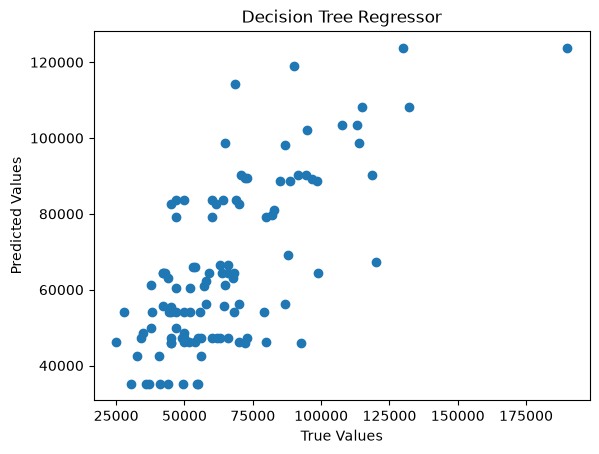

In [51]:
plt.figure()
plt.scatter(y_test, y_pred_test)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Decision Tree Regressor')
plt.show()

In [52]:
oh = None
if categorial_features:
    oh = best_model.named_steps["preprocessor"].transformers_[1][1].named_steps['onehot']
num_names = numeric_features
cat_names = oh.get_feature_names_out(categorial_features).tolist() if oh is not None else []
feature_names = num_names + cat_names
feature_names

['lotsize',
 'bedrooms',
 'bathrms',
 'stories',
 'garagepl',
 'driveway_no',
 'driveway_yes',
 'recroom_no',
 'recroom_yes',
 'fullbase_no',
 'fullbase_yes',
 'gashw_no',
 'gashw_yes',
 'airco_no',
 'airco_yes',
 'prefarea_no',
 'prefarea_yes']

In [53]:
importances = best_model.named_steps['tree'].feature_importances_
imp_df = (pd.DataFrame({
    'feature': feature_names if len(feature_names) == len(importances) else [f"feature_{i}" for i in range(len(importances))],
    'importance': importances})
          .sort_values(by='importance', ascending=False).head(10)
)
imp_df

,feature,importance
0,lotsize,0.520491
2,bathrms,0.167565
3,stories,0.058164
10,fullbase_yes,0.053454
13,airco_no,0.047825
4,garagepl,0.046070
14,airco_yes,0.030663
1,bedrooms,0.027517
12,gashw_yes,0.023941
15,prefarea_no,0.012288


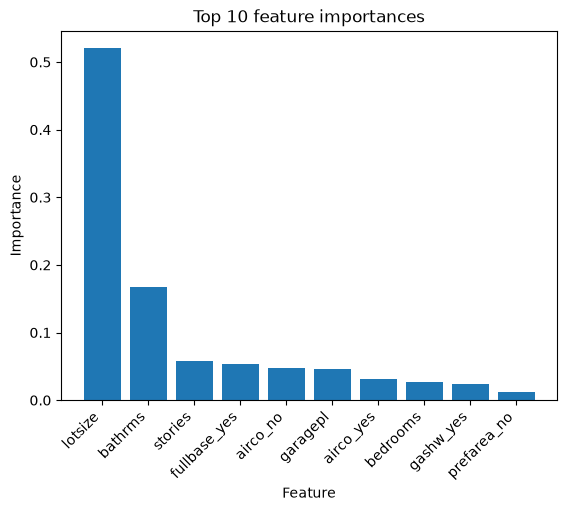

In [54]:
plt.figure()
plt.bar(imp_df['feature'], imp_df['importance'])
plt.title('Top 10 feature importances')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.show()